## STEAM GAMES RECOMMENDATION EDA

This notebook provides an exploratory data analysis (EDA) of the Steam games dataset. The dataset contains information about various games available on the Steam platform, including their genres, tags, and review statistics. The EDA aims to understand the dataset's structure, identify patterns, and gain insights into the games characteristics.


In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Load the data and perform a basic EDA to see the structure of the data.

In [4]:
# Define Path
PROJECT_ROOT = Path.cwd().parent
from src.ingestion import load_data

data_path = PROJECT_ROOT / 'data' / 'raw' / 'games.json'

# Load data
df = load_data(data_path)
display(df.head())
print(df.info())

Loading data from /home/axel/grec/data/raw/games.json...
Successfully loaded 122611 records.


,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,...,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,,,,,https://shared.akamai.steamstatic.com/store_it...,...,0,0,0 - 0,0,0,0,0,0,0,[]
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,...,252,3,0 - 20000,8,0,8,0,65,0,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':..."
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,...,21,3,0 - 20000,0,0,0,0,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4..."
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0,0 - 20000,0,0,0,0,0,1,[]
3631080,Maze Quest VR,"Apr 24, 2025",0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0,0 - 20000,0,0,0,0,0,0,[]


<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 42 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   name                      122611 non-null  object 
 1   release_date              122611 non-null  object 
 2   required_age              122611 non-null  int64  
 3   price                     122611 non-null  float64
 4   dlc_count                 122611 non-null  int64  
 5   detailed_description      122611 non-null  object 
 6   about_the_game            122611 non-null  object 
 7   short_description         122611 non-null  object 
 8   reviews                   122611 non-null  object 
 9   header_image              122611 non-null  object 
 10  website                   122611 non-null  object 
 11  support_url               122611 non-null  object 
 12  support_email             122611 non-null  object 
 13  windows                   122611 non-null 

Only keep and analyze the following relevant columns for the system. Also, drop any rows with missing values.


In [5]:
# Select potential columns needed for the system
cols_to_keep = ['name', 'genres', 'tags', 'positive', 'negative', 'short_description']

# Select the columns
df = df[cols_to_keep]

# Print number of rows (instances)
print("Number of rows:", df.shape[0])

# Remove rows with empty name
df = df[df['name'].str.strip() != '']
print("Number of rows after removing empty names:", df.shape[0])

# Remove rows with empty genres
df = df[df['genres'].str.len() > 0]
print("Number of rows after removing empty genres:", df.shape[0])

# Remove rows with empty tags
df = df[df['tags'].str.len() > 0]
print("Number of rows after removing empty tags:", df.shape[0])

# Remove rows with 0 positive or 0 negative
df = df[(df['positive'] > 0) & (df['negative'] > 0)]
print("Number of rows after removing 0 positive and 0 negative:", df.shape[0])

# Remove rows with empty short description
df = df[df['short_description'].str.strip() != '']
print("Number of rows after removing empty short descriptions:", df.shape[0])

# # Remove rows with empty supported languages
# df = df[df['supported_languages'].str.len() > 0]
# print("Number of rows after removing games with no supported languages:", df.shape[0])

# # Remove rows with empty estimated owners
# df = df[df['estimated_owners'] != '0 - 0']
# print("Number of rows after removing games with 0 estimated owners:", df.shape[0])

Number of rows: 122611
Number of rows after removing empty names: 122610
Number of rows after removing empty genres: 114198
Number of rows after removing empty tags: 83235
Number of rows after removing 0 positive and 0 negative: 64697
Number of rows after removing empty short descriptions: 64686


The dataset reduced nearly by half by just removing rows with columns with missing values. Lets see the distribution of values of positive and negative columns.

           positive      negative
count  6.468600e+04  6.468600e+04
mean   1.975686e+03  3.202187e+02
std    3.865009e+04  7.396303e+03
min    1.000000e+00  1.000000e+00
25%    9.000000e+00  3.000000e+00
50%    3.100000e+01  9.000000e+00
75%    1.600000e+02  4.200000e+01
max    7.642084e+06  1.173003e+06


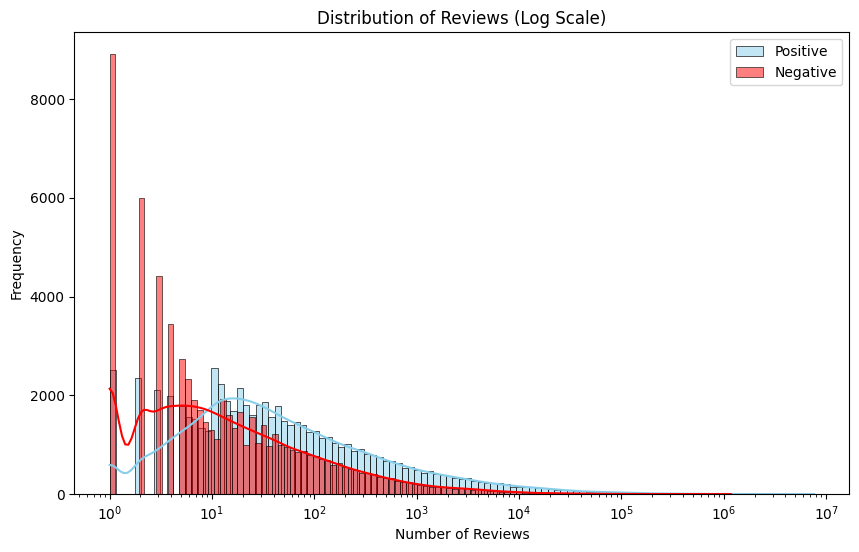

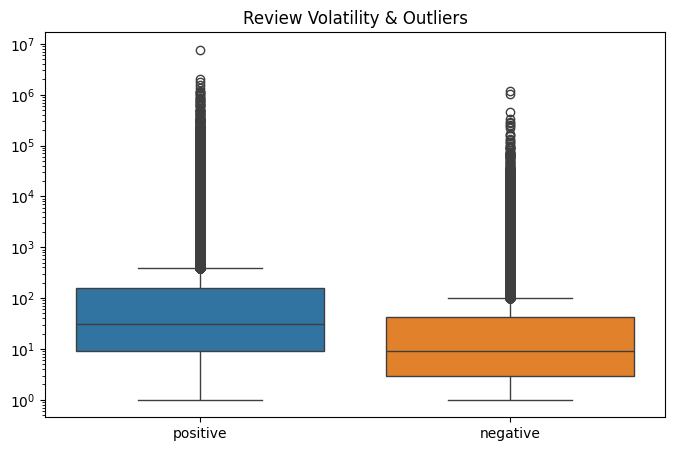

In [6]:
# Basic stats for positive and negative reviews
print(df[['positive', 'negative']].describe())

# Histogram of positive and negative reviews (log scale)
plt.figure(figsize=(10, 6))
sns.histplot(df['positive'], color="skyblue", label='Positive', kde=True, log_scale=True)
sns.histplot(df['negative'], color="red", label='Negative', kde=True, log_scale=True)
plt.title('Distribution of Reviews (Log Scale)')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Boxplot of positive and negative reviews (log scale)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['positive', 'negative']])
plt.yscale('log')
plt.title('Review Volatility & Outliers')
plt.show()

The plots show that the vast majority of games have very few reviews and a few games have a lot of reviews. The games with few reviews are not representative. We will only consider games with at least 100 reviews by applying a hard threshold.

Number of rows after removing games with less than 100 reviews: 22698


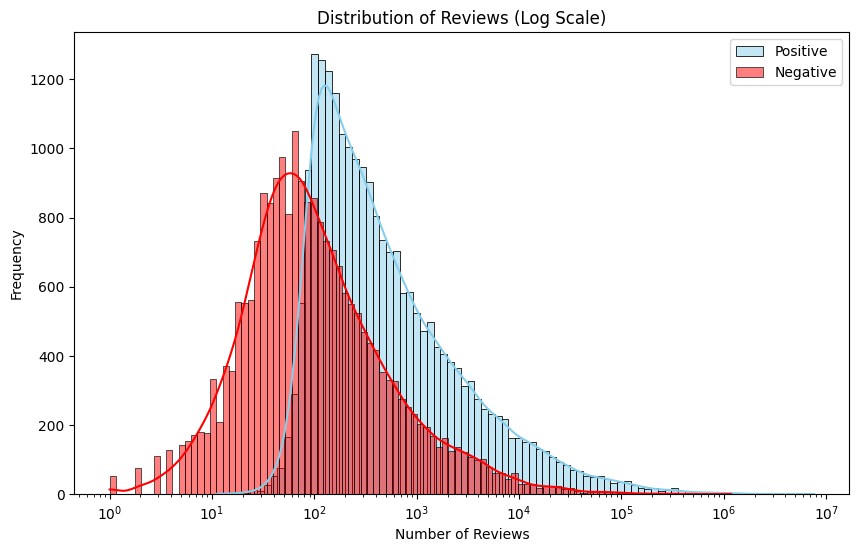

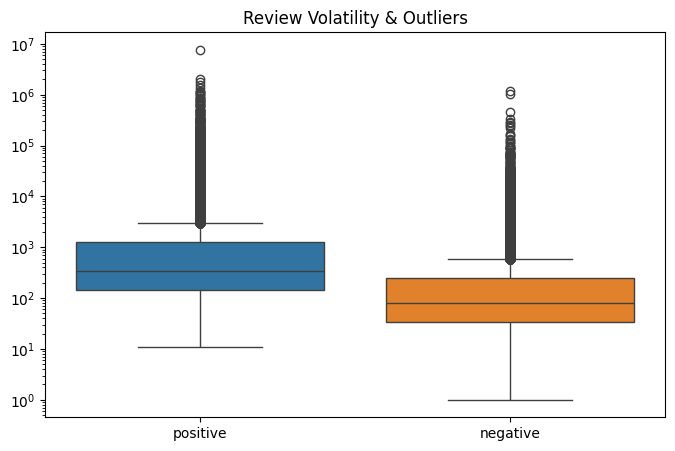

In [7]:
# Remove games with less than 100 reviews
df = df[df['positive'] + df['negative'] >= 100]
print("Number of rows after removing games with less than 100 reviews:", df.shape[0])

# Histogram of positive and negative reviews (log scale)
plt.figure(figsize=(10, 6))
sns.histplot(df['positive'], color="skyblue", label='Positive', kde=True, log_scale=True)
sns.histplot(df['negative'], color="red", label='Negative', kde=True, log_scale=True)
plt.title('Distribution of Reviews (Log Scale)')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Boxplot of positive and negative reviews (log scale)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['positive', 'negative']])
plt.yscale('log')
plt.title('Review Volatility & Outliers')
plt.show()

In [8]:
# Study the column name, check for duplicates
df['name'].duplicated().sum()
dups = df[df['name'].duplicated(keep=False)].sort_values('name')
dups.head(20)

,name,genres,tags,positive,negative,short_description
34010,Alpha Protocol™,"[Action, RPG]","{'RPG': 498, 'Stealth': 396, 'Choices Matter':...",3988,923,Loyalty carries a price and no one knows this ...
34019,Alpha Protocol™,"[Action, RPG]","{'RPG': 485, 'Stealth': 384, 'Action': 313, 'C...",3244,801,Loyalty carries a price and no one knows this ...
33230,Assassin's Creed 2,"[Action, Adventure]","{'Action': 878, 'Open World': 783, 'Parkour': ...",48815,5831,"An epic story of family, vengeance and conspir..."
48173,Assassin's Creed 2,"[Action, Adventure]","{'Action': 726, 'Open World': 635, 'Parkour': ...",15726,2734,"An epic story of family, vengeance and conspir..."
22362,BRINK,"[Action, Free To Play]","{'FPS': 295, 'Action': 246, 'Multiplayer': 231...",3657,2383,You decide the combat role you want to assume ...
22360,BRINK,"[Action, Free To Play]","{'FPS': 295, 'Action': 246, 'Multiplayer': 231...",3657,2384,You decide the combat role you want to assume ...
22350,BRINK,"[Action, Free To Play]","{'FPS': 329, 'Action': 261, 'Multiplayer': 252...",4999,2954,You decide the combat role you want to assume ...
35140,Batman: Arkham Asylum Game of the Year Edition,"[Action, Adventure]","{'Action': 1259, 'Stealth': 896, 'Third Person...",70940,2711,Experience what it’s like to be Batman and fac...
35010,Batman: Arkham Asylum Game of the Year Edition,"[Action, Adventure]","{'Action': 1087, 'Batman': 981, 'Stealth': 736...",21567,916,Experience what it’s like to be Batman and fac...
209650,Call of Duty®: Advanced Warfare - Gold Edition,[Action],"{'Dog': 2828, 'FPS': 2179, 'Action': 1856, 'Mu...",16240,8817,Call of Duty®: Advanced Warfare envisions a po...


The are two main cases:
-   Difference in short_description means that they are different games, keep the games.
-   No difference in short_description, they are the same game, multiple records. These cases likely correspond to the same game captured at different points in time or through multiple store entries. Keep the one with the highest total number of reviews (positive + negative).

In [9]:
# Function to handle duplicates
def remove_redundant_duplicates(df):
    # Identify duplicates by name
    duplicated_names = df[df['name'].duplicated(keep=False)]['name'].unique()
    
    rows_to_keep = []
    rows_to_remove = []
    
    for name in duplicated_names:
        subset = df[df['name'] == name].copy()

        subset['desc_clean'] = (
            subset['short_description']
            .str.lower()
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
        )
        
        # Check if short_description differs (different games with same name)
        if subset['desc_clean'].nunique() > 1:
            # Keep all - they are different games
            print(f"Keeping all {len(subset)} versions of '{name}' - Different descriptions (different games)")
            rows_to_keep.extend(subset.index.tolist())
        else:
            # Same game, different snapshots - keep the one with most reviews
            subset['total_reviews'] = subset['positive'] + subset['negative']
            best_idx = subset['total_reviews'].idxmax()
            
            print(f"'{name}' - Keeping version with {subset.loc[best_idx, 'total_reviews']} reviews, removing {len(subset)-1} duplicates")
            rows_to_keep.append(best_idx)
            rows_to_remove.extend([idx for idx in subset.index if idx != best_idx])
    
    # Keep all non-duplicated rows
    non_duplicated = df[~df['name'].duplicated(keep=False)].index.tolist()
    rows_to_keep.extend(non_duplicated)
    
    # Create cleaned dataframe
    df_cleaned = df.loc[rows_to_keep].copy()
    
    print(f"\n{'='*80}")
    print(f"Original rows: {len(df)}")
    print(f"Rows removed: {len(rows_to_remove)}")
    print(f"Final rows: {len(df_cleaned)}")
    print(f"{'='*80}")
    
    return df_cleaned

# Apply the function
df_cleaned = remove_redundant_duplicates(df)

# Verify no redundant duplicates remain
print("\nVerification - Remaining duplicates:")
remaining_dups = df_cleaned[df_cleaned['name'].duplicated(keep=False)].sort_values('name')
if len(remaining_dups) > 0:
    print(f"Found {remaining_dups['name'].nunique()} games with duplicate names (different games):")
    for name in remaining_dups['name'].unique()[:10]:
        subset = remaining_dups[remaining_dups['name'] == name]
        print(f"  - {name}: {len(subset)} versions with different descriptions")
else:
    print("No duplicates remaining!")

# Update df
df = df_cleaned

'Shadow of the Tomb Raider: Definitive Edition' - Keeping version with 79443 reviews, removing 19 duplicates
'Call of Duty®: Black Ops III' - Keeping version with 215026 reviews, removing 2 duplicates
Keeping all 2 versions of 'First Snow' - Different descriptions (different games)
'Civilization IV: Beyond the Sword' - Keeping version with 4592 reviews, removing 1 duplicates
Keeping all 3 versions of 'Hide and Seek' - Different descriptions (different games)
'Ethan: Meteor Hunter' - Keeping version with 249 reviews, removing 1 duplicates
Keeping all 2 versions of 'Outpost' - Different descriptions (different games)
Keeping all 2 versions of 'Flashback' - Different descriptions (different games)
'Sword of the Stars: Complete Collection' - Keeping version with 677 reviews, removing 1 duplicates
'Trine 2: Complete Story' - Keeping version with 21679 reviews, removing 1 duplicates
'RIP - Trilogy™' - Keeping version with 382 reviews, removing 2 duplicates
Keeping all 2 versions of 'Lighthou

In [10]:
# As there are still duplicates, we add the unique identifier (app_id) as a new column to the dataframe so is it possible to identify each game
df = df.reset_index().rename(columns={'index': 'app_id'})

Check for possible values of tags and genre 

In [11]:
# GENRES ANALYSIS
print("="*80)
print("GENRES")
print("="*80)

# Flatten and count all genres
from collections import Counter

all_genres = []
for genres_list in df['genres']:
    all_genres.extend(genres_list)

genre_counts = Counter(all_genres)
print(f"\nTotal unique genres: {len(genre_counts)}")
print(f"\nAll genres with frequencies:")
for genre, count in genre_counts.most_common():
    percentage = (count / len(df)) * 100
    print(f"  {genre}: {count} games ({percentage:.1f}%)")

# TAGS ANALYSIS
print("\n" + "="*80)
print("TAGS")
print("="*80)

# Flatten and count all tags
all_tags = Counter()
tag_votes = Counter()

for tags_dict in df['tags']:
    if isinstance(tags_dict, dict):
        all_tags.update(tags_dict.keys())
        for tag, votes in tags_dict.items():
            tag_votes[tag] += votes

print(f"\nTotal unique tags: {len(all_tags)}")
print(f"\nTop 50 most common tags:")
for tag, count in all_tags.most_common(50):
    percentage = (count / len(df)) * 100
    avg_votes = tag_votes[tag] / count if count > 0 else 0
    print(f"  {tag}: {count} games ({percentage:.1f}%) - {tag_votes[tag]:,} total votes (avg: {avg_votes:.0f})")

GENRES

Total unique genres: 28

All genres with frequencies:
  Indie: 15146 games (67.0%)
  Adventure: 9808 games (43.4%)
  Action: 9643 games (42.6%)
  Casual: 7105 games (31.4%)
  Simulation: 5562 games (24.6%)
  RPG: 5343 games (23.6%)
  Strategy: 5066 games (22.4%)
  Free To Play: 2071 games (9.2%)
  Early Access: 1533 games (6.8%)
  Sports: 958 games (4.2%)
  Racing: 793 games (3.5%)
  Massively Multiplayer: 777 games (3.4%)
  Utilities: 168 games (0.7%)
  Design & Illustration: 113 games (0.5%)
  Animation & Modeling: 93 games (0.4%)
  Violent: 71 games (0.3%)
  Video Production: 58 games (0.3%)
  Game Development: 53 games (0.2%)
  Gore: 49 games (0.2%)
  Education: 45 games (0.2%)
  Web Publishing: 40 games (0.2%)
  Audio Production: 38 games (0.2%)
  Software Training: 33 games (0.1%)
  Sexual Content: 25 games (0.1%)
  Nudity: 25 games (0.1%)
  Photo Editing: 25 games (0.1%)
  Accounting: 3 games (0.0%)
  Movie: 1 games (0.0%)

TAGS

Total unique tags: 448

Top 50 most commo

Tags are more descriptives and specific than genres. Should be more important than genres when searching for similar games. 